In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [204]:
df=pd.read_csv('crop_recommendation.csv')

In [205]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,district
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,ryk
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,bahawalnagar
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,bwp
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,rajanpur
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,digikhan


# EDA

In [206]:
df.shape

(2200, 9)

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
 8   district     2200 non-null   object 
dtypes: float64(4), int64(3), object(2)
memory usage: 154.8+ KB


In [208]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [209]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
district       0
dtype: int64

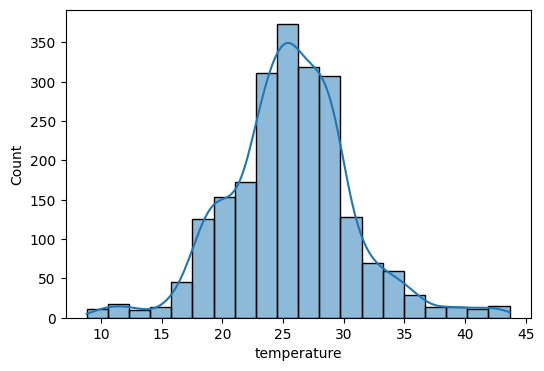

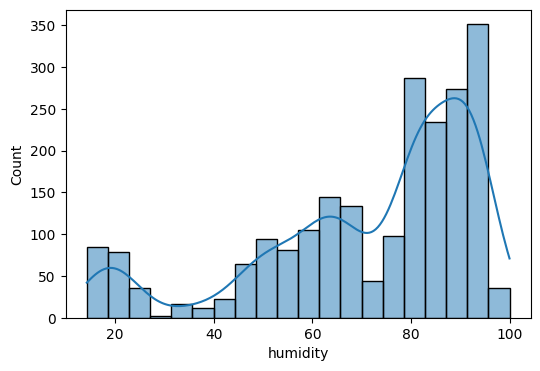

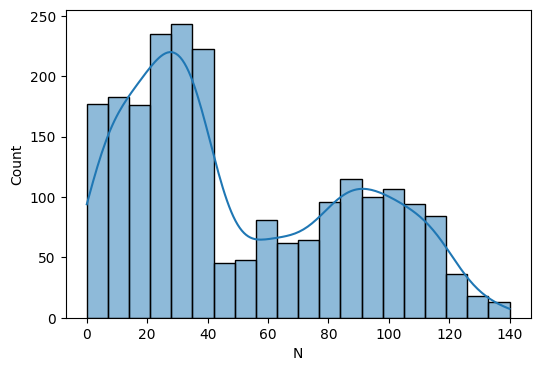

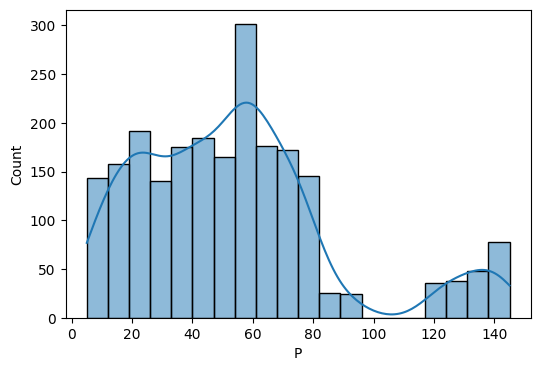

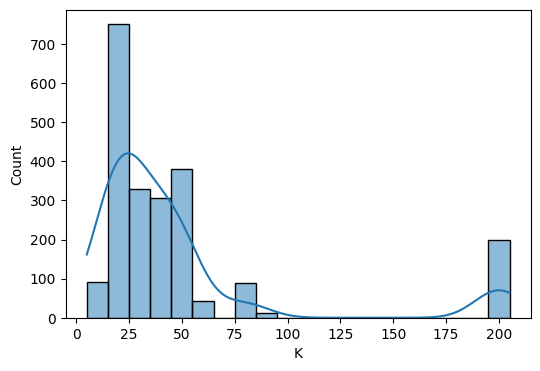

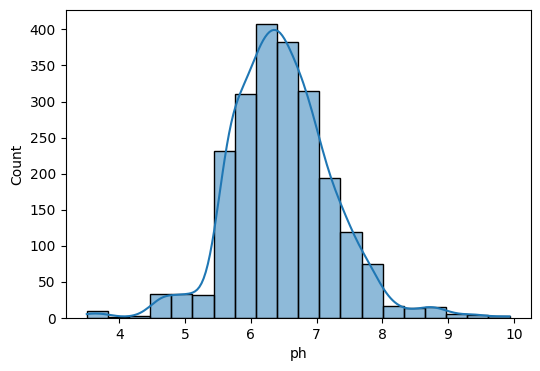

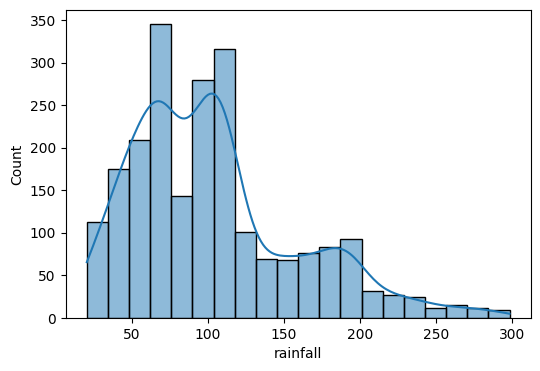

In [210]:
num_col=['temperature','humidity','N','P','K','ph','rainfall'
         ]
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'rice'),
  Text(1, 0, 'maize'),
  Text(2, 0, 'pulses'),
  Text(3, 0, 'millets'),
  Text(4, 0, 'sugarcane'),
  Text(5, 0, 'mungbean'),
  Text(6, 0, 'blackgram'),
  Text(7, 0, 'lentil'),
  Text(8, 0, 'wheat'),
  Text(9, 0, 'banana'),
  Text(10, 0, 'mango'),
  Text(11, 0, 'grapes'),
  Text(12, 0, 'cotton')])

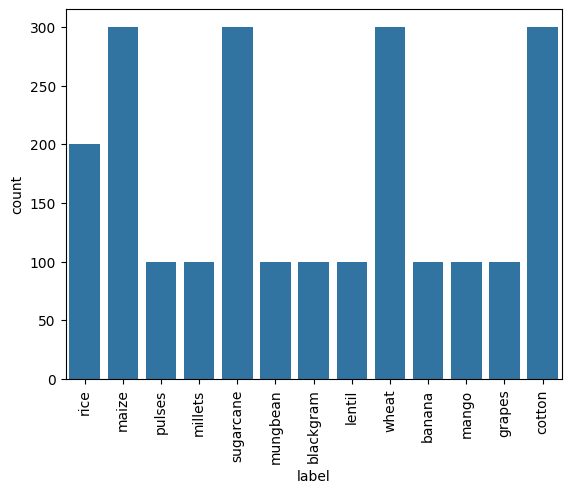

In [211]:
sns.countplot(x=df['label'])
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38],
 [Text(0, 0, 'ryk'),
  Text(1, 0, 'bahawalnagar'),
  Text(2, 0, 'bwp'),
  Text(3, 0, 'rajanpur'),
  Text(4, 0, 'digikhan'),
  Text(5, 0, 'layyah'),
  Text(6, 0, 'm.garh'),
  Text(7, 0, 'vihari'),
  Text(8, 0, 'khanewal'),
  Text(9, 0, 'lodhran'),
  Text(10, 0, 'multan'),
  Text(11, 0, 'pakpatan'),
  Text(12, 0, 'sahiwal'),
  Text(13, 0, 'okara'),
  Text(14, 0, 'kasur'),
  Text(15, 0, 'lahore'),
  Text(16, 0, 'nankana sahib'),
  Text(17, 0, 'shekupora'),
  Text(18, 0, 'hafizabad'),
  Text(19, 0, 'gujranwala'),
  Text(20, 0, 'narowall'),
  Text(21, 0, 'sialkot'),
  Text(22, 0, 'gujrat'),
  Text(23, 0, 'chainiot'),
  Text(24, 0, 'jhang'),
  Text(25, 0, 'faisalabad'),
  Text(26, 0, 'bakar'),
  Text(27, 0, 'mianwali'),
  Text(28, 0, 'tobataiksingh'),
  Text(29, 0, 'atto

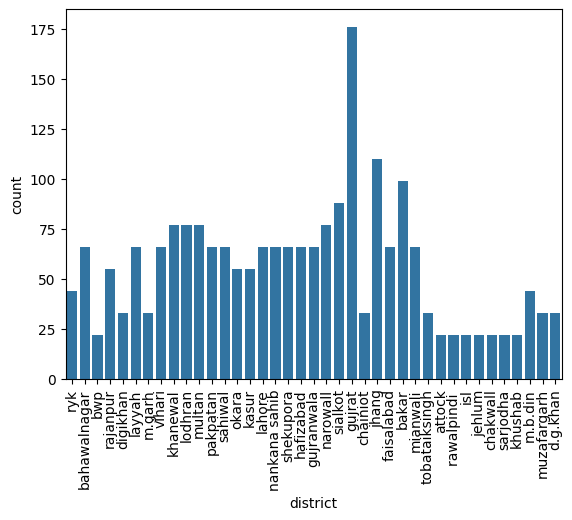

In [212]:
sns.countplot(x=df['district'])
plt.xticks(rotation=90)

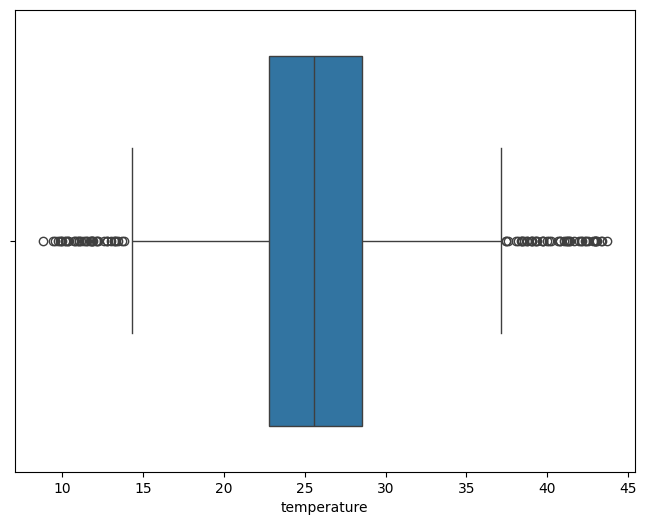

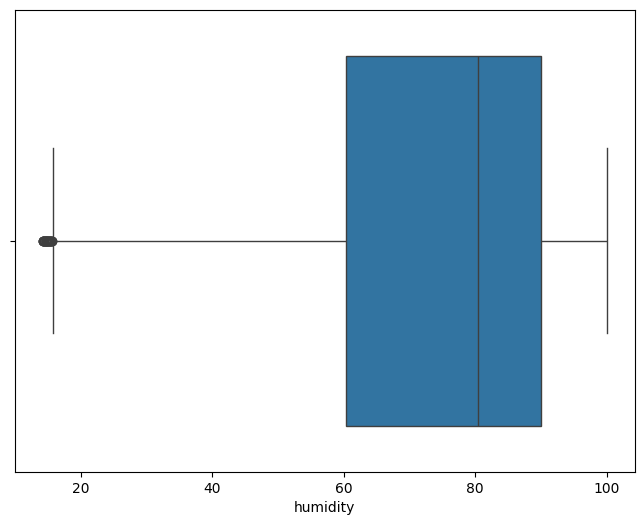

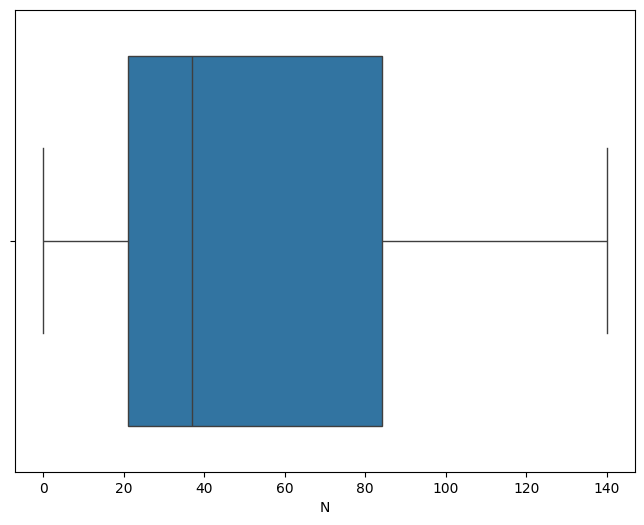

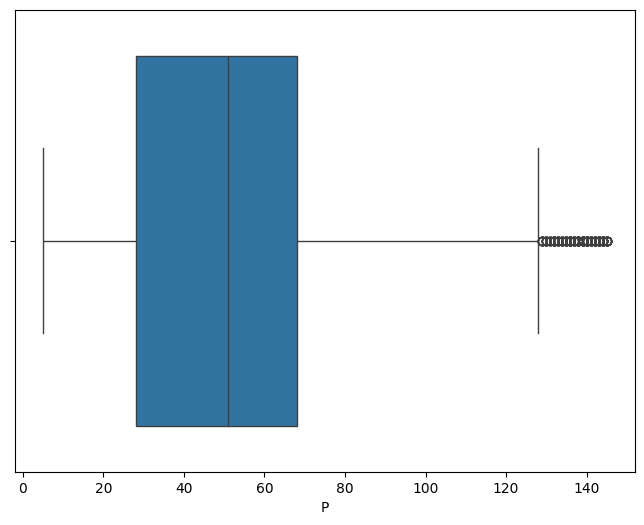

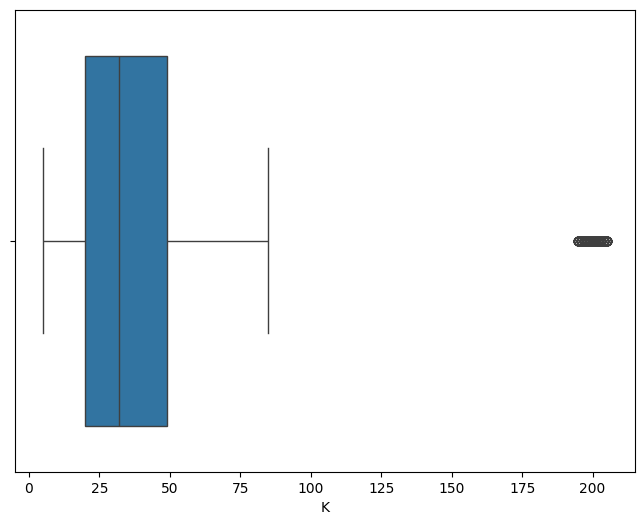

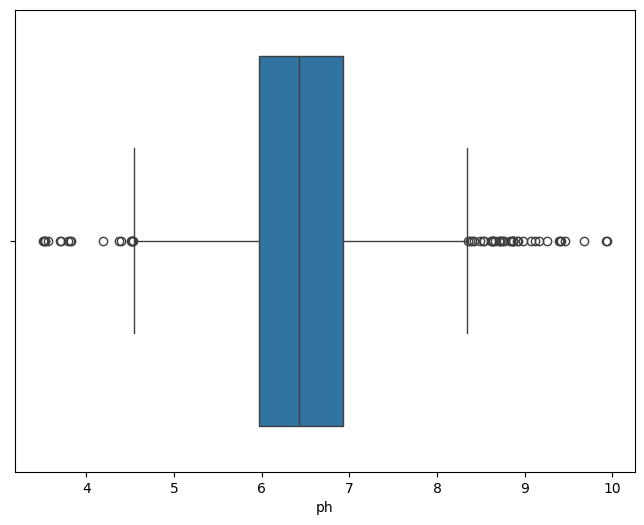

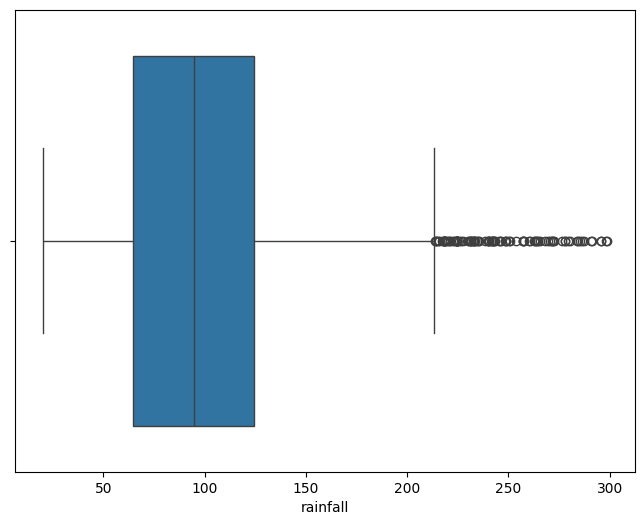

In [213]:
for col in num_col:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=df[col])

<Axes: >

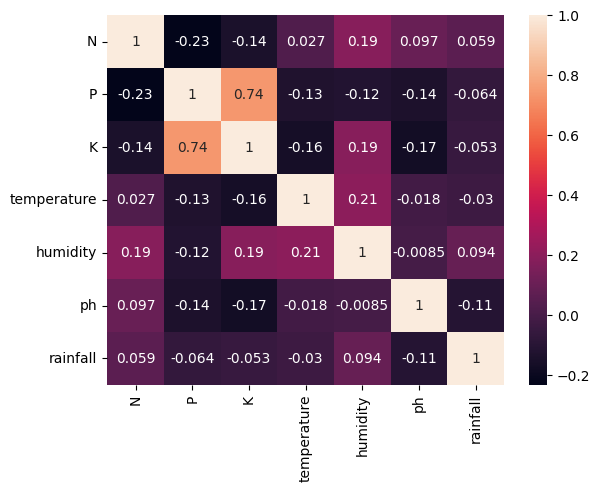

In [214]:
plt.Figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning and preprocessing

In [215]:
df_clean=df.copy()

In [216]:
df_clean.head()

,N,P,K,temperature,humidity,ph,rainfall,label,district
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,ryk
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,bahawalnagar
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,bwp
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,rajanpur
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,digikhan


<Axes: xlabel='P', ylabel='Count'>

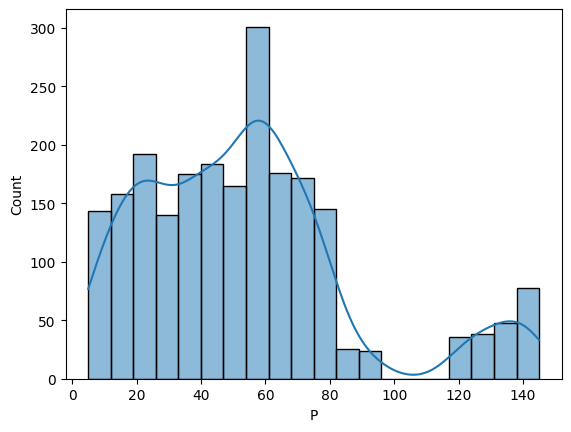

In [217]:
sns.histplot(x=df_clean['P'],kde=True, bins=20)

In [218]:
df_clean['P'] = np.sqrt(df_clean['P'])

<Axes: xlabel='P', ylabel='Count'>

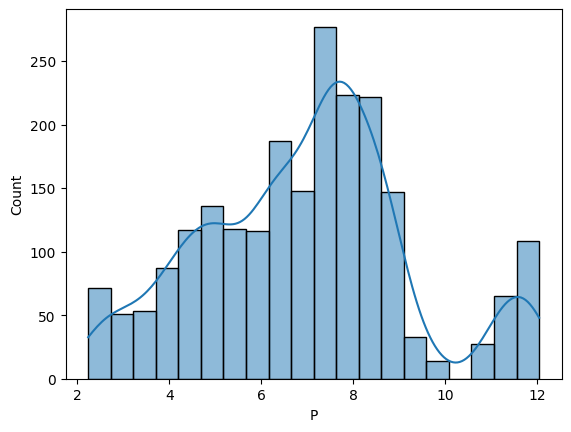

In [219]:
sns.histplot(x=df_clean['P'],kde=True, bins=20)

<Axes: xlabel='K', ylabel='Count'>

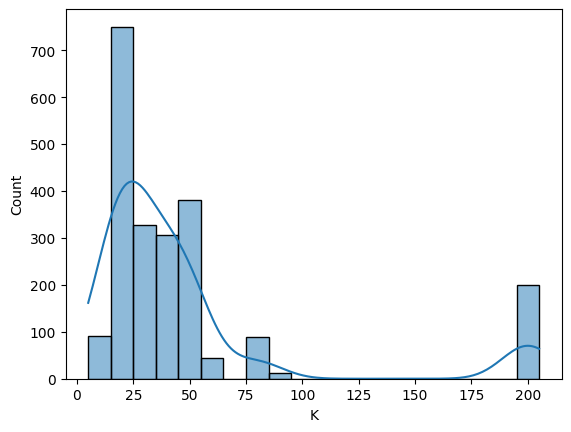

In [220]:
sns.histplot(x=df_clean['K'],kde=True, bins=20)

In [221]:
df_clean['K'] = np.log1p(df_clean['K'])

<Axes: xlabel='K', ylabel='Count'>

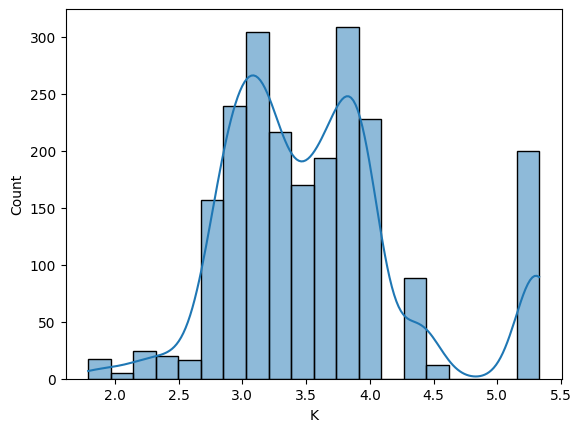

In [222]:
sns.histplot(x=df_clean['K'],kde=True, bins=20)

In [223]:
df_clean.head()

,N,P,K,temperature,humidity,ph,rainfall,label,district
0,90,6.480741,3.784190,20.879744,82.002744,6.502985,202.935536,rice,ryk
1,85,7.615773,3.737670,21.770462,80.319644,7.038096,226.655537,rice,bahawalnagar
2,60,7.416198,3.806662,23.004459,82.320763,7.840207,263.964248,rice,bwp
3,74,5.916080,3.713572,26.491096,80.158363,6.980401,242.864034,rice,rajanpur
4,78,6.480741,3.761200,20.130175,81.604873,7.628473,262.717340,rice,digikhan


In [224]:
df_clean.rename(columns={'label': 'crop'}, inplace=True)

In [225]:
df_clean.head()

,N,P,K,temperature,humidity,ph,rainfall,crop,district
0,90,6.480741,3.784190,20.879744,82.002744,6.502985,202.935536,rice,ryk
1,85,7.615773,3.737670,21.770462,80.319644,7.038096,226.655537,rice,bahawalnagar
2,60,7.416198,3.806662,23.004459,82.320763,7.840207,263.964248,rice,bwp
3,74,5.916080,3.713572,26.491096,80.158363,6.980401,242.864034,rice,rajanpur
4,78,6.480741,3.761200,20.130175,81.604873,7.628473,262.717340,rice,digikhan


In [226]:
df_clean['district'].value_counts()

district
gujrat           176
jhang            110
bakar             99
sialkot           88
khanewal          77
narowall          77
multan            77
lodhran           77
faisalabad        66
sahiwal           66
mianwali          66
nankana sahib     66
layyah            66
bahawalnagar      66
lahore            66
hafizabad         66
shekupora         66
pakpatan          66
vihari            66
gujranwala        66
rajanpur          55
okara             55
kasur             55
m.b.din           44
ryk               44
digikhan          33
m.garh            33
d.g.khan          33
chainiot          33
muzafargarh       33
tobataiksingh     33
bwp               22
attock            22
rawalpindi        22
isl               22
sarjodha          22
chakwall          22
jehlum            22
khushab           22
Name: count, dtype: int64

In [227]:
district_freq = df_clean['district'].value_counts(normalize=True)
df_clean['district'] = df_clean['district'].map(district_freq)

In [228]:
df_clean.head()

,N,P,K,temperature,humidity,ph,rainfall,crop,district
0,90,6.480741,3.784190,20.879744,82.002744,6.502985,202.935536,rice,0.020
1,85,7.615773,3.737670,21.770462,80.319644,7.038096,226.655537,rice,0.030
2,60,7.416198,3.806662,23.004459,82.320763,7.840207,263.964248,rice,0.010
3,74,5.916080,3.713572,26.491096,80.158363,6.980401,242.864034,rice,0.025
4,78,6.480741,3.761200,20.130175,81.604873,7.628473,262.717340,rice,0.015


In [229]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
encoder = LabelEncoder()

df_clean['crop'] = encoder.fit_transform(df_clean['crop'])

In [230]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

numerical_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
df_clean[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])

In [231]:
df_clean.sample(3)

,N,P,K,temperature,humidity,ph,rainfall,crop,district
1691,0.264286,0.271573,0.239613,0.296075,0.891845,0.676461,0.315474,12,0.08
798,0.314286,0.666858,0.367432,0.683318,0.548772,0.594405,0.149552,1,0.03
1116,0.264286,0.400626,0.482096,0.660887,0.364811,0.297432,0.256323,6,0.03


# Model

In [232]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [233]:
X = df_clean[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'district']]  # Features
y = df_clean['crop']

In [234]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

model = RandomForestClassifier(
    n_estimators=50,          
    max_depth=4,              
    min_samples_leaf=25,      
    max_features=3,           
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,25
,min_weight_fraction_leaf,0.0
,max_features,4
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [236]:
y_pred = model.predict(X_test)

In [237]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Print detailed classification report
print(classification_report(y_test, y_pred))

Accuracy: 90.68%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       0.00      0.00      0.00        20
           2       0.92      1.00      0.96        61
           3       1.00      1.00      1.00        14
           4       1.00      1.00      1.00        11
           5       1.00      0.93      0.96        57
           6       1.00      0.89      0.94        19
           7       1.00      0.95      0.97        20
           8       0.90      1.00      0.95        19
           9       1.00      1.00      1.00        26
          10       0.91      0.76      0.83        42
          11       0.70      0.94      0.80        70
          12       0.95      1.00      0.98        60

    accuracy                           0.91       440
   macro avg       0.88      0.88      0.88       440
weighted avg       0.88      0.91      0.89       440



In [238]:
from sklearn.model_selection import cross_val_score

cross_val_accuracy = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy: {cross_val_accuracy.mean():.2f}")


Cross-validation accuracy: 0.77


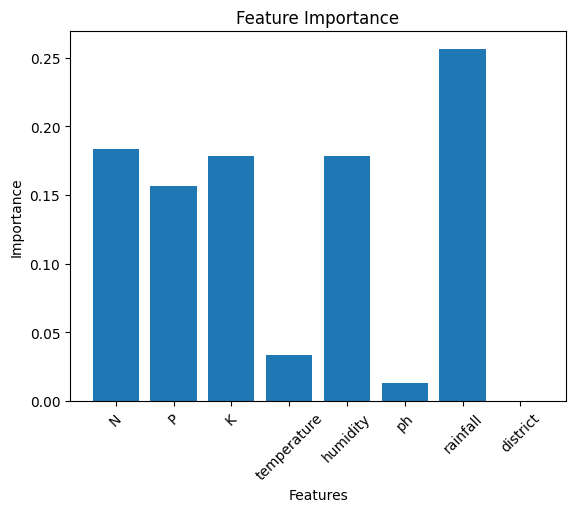

In [239]:
import matplotlib.pyplot as plt


feature_importances = model.feature_importances_

# Create a bar plot
plt.bar(X.columns, feature_importances)
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

In [240]:
import joblib
joblib.dump(encoder, 'crop_recomend_label_encoder.joblib')  # Save the LabelEncoder
joblib.dump(scaler, 'crop_recomend_minmax_scaler.joblib')   # Save the MinMaxScaler
joblib.dump(model, 'crop_recomend_model.joblib')  # Save the trained model

['crop_recomend_model.joblib']